# Model B — Claim Outcome Classification 

**Changes from v1:**
- Interaction features: `bill_vs_dept_avg`, `bill_x_provider_rate`, `lag_x_amount`, `chronic_x_amount`
- SMOTE oversampling on Rejected class **inside** `TimeSeriesSplit` folds
- Reduced GB complexity (`max_depth=4`, `min_samples_leaf=20`) to close overfit gap
- Probability threshold tuned for Rejected class recall
- `TimeSeriesSplit` replaces `StratifiedKFold`

In [1]:
import warnings, json, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)
SCHEMA_PATH = Path('feature_schema.json')

print('Libraries loaded.')

Libraries loaded.


## 1. Load & Engineer Features

In [2]:
df = pd.read_csv(
    '../Phase2_EDA/model_table.csv',
    parse_dates=['visit_date', 'billing_date', 'registration_date']
)
df = df.sort_values('visit_date').reset_index(drop=True)

# ── Original engineered feature ──────────────────────────────────────────────
df['billed_per_hour'] = np.where(
    df['length_of_stay_hours'] > 0,
    (df['billed_amount'] / df['length_of_stay_hours']).round(2), 0
)

# ── Interaction features (new in v2) ─────────────────────────────────────────
df['bill_vs_dept_avg']     = (df['billed_amount'] / (df['dept_avg_billed'] + 1)).round(4)
df['bill_x_provider_rate'] = (df['billed_amount'] * df['provider_rejection_rate']).round(2)
df['lag_x_amount']         = (df['billing_lag']   * df['billed_amount']).round(2)
df['chronic_x_amount']     = (df['chronic_flag']  * df['billed_amount']).round(2)

print(f'Shape: {df.shape}')
print(f'Date range: {df["visit_date"].min().date()} → {df["visit_date"].max().date()}')
print('\nTarget distribution:')
print(df['claim_status'].value_counts())

Shape: (25000, 39)
Date range: 2025-01-20 → 2026-01-20

Target distribution:
claim_status
Paid        14940
Pending      6263
Rejected     3797
Name: count, dtype: int64


## 2. Feature Set & Target Encoding

In [3]:
TARGET = 'claim_status'

NUMERIC_FEATURES = [
    'billed_amount', 'billed_per_hour', 'provider_rejection_rate',
    'dept_avg_billed', 'age', 'chronic_flag', 'billing_lag',
    'visit_month', 'visit_quarter', 'outlier_billed',
    'length_of_stay_hours', 'visit_frequency',
    # interaction features
    'bill_vs_dept_avg', 'bill_x_provider_rate', 'lag_x_amount', 'chronic_x_amount',
]
CATEGORICAL_FEATURES = ['insurance_provider', 'visit_type', 'department', 'risk_score']

df_model = df.copy()
le_dict_claim = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict_claim[col] = list(le.classes_)

ENCODED_CATS = [c + '_enc' for c in CATEGORICAL_FEATURES]
ALL_FEATURES = NUMERIC_FEATURES + ENCODED_CATS

claim_le = LabelEncoder()
df_model['claim_label'] = claim_le.fit_transform(df_model[TARGET])
print('Claim classes:', claim_le.classes_)
print(f'Feature matrix: {len(ALL_FEATURES)} features  (was 16, now {len(ALL_FEATURES)})')

Claim classes: ['Paid' 'Pending' 'Rejected']
Feature matrix: 20 features  (was 16, now 20)


## 3. Time-Based Train / Test Split (80 / 20)

In [4]:
X = df_model[ALL_FEATURES]
y = df_model['claim_label']
dates = df_model['visit_date']

split_idx = int(len(df_model) * 0.80)
split_date = dates.iloc[split_idx]

X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

print(f'Split date : {split_date.date()}')
print(f'Train      : {len(X_train):,}  |  Test: {len(X_test):,}')
print('\nClass distribution (train):')
for cls, cnt in zip(claim_le.classes_, np.bincount(y_train)):
    print(f'  {cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)')

Split date : 2025-11-08
Train      : 20,000  |  Test: 5,000

Class distribution (train):
  Paid: 11943 (59.7%)
  Pending: 4988 (24.9%)
  Rejected: 3069 (15.3%)


## 4. Baseline — Logistic Regression (reference)

In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print('=== Baseline: Logistic Regression ===')
print(f'Train Acc: {accuracy_score(y_train, lr_pipe.predict(X_train)):.4f}  |  Test Acc: {accuracy_score(y_test, y_pred_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=claim_le.classes_))

=== Baseline: Logistic Regression ===
Train Acc: 0.3286  |  Test Acc: 0.3376


              precision    recall  f1-score   support

        Paid       0.65      0.30      0.41      2997
     Pending       0.27      0.44      0.33      1275
    Rejected       0.16      0.34      0.21       728

    accuracy                           0.34      5000
   macro avg       0.36      0.36      0.32      5000
weighted avg       0.48      0.34      0.36      5000



## 5. SMOTE + Gradient Boosting (v2 Core Fix)

SMOTE targets the **Rejected** class (most under-represented and highest business cost if missed).  
GB complexity is reduced to prevent memorising the training set.

In [6]:
rej_idx = list(claim_le.classes_).index('Rejected')
paid_idx = list(claim_le.classes_).index('Paid')
pend_idx = list(claim_le.classes_).index('Pending')

# Upsample Rejected to 60% of Paid count; Pending to 80% of Paid
paid_count = int((y_train == paid_idx).sum())
sampling_strategy = {
    rej_idx:  int(paid_count * 0.60),
    pend_idx: int(paid_count * 0.80),
}
print('SMOTE target counts:', {claim_le.classes_[k]: v for k, v in sampling_strategy.items()})

smote_gb_pipe = ImbPipeline([
    ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=5)),
    ('clf', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,           # reduced from 5
        min_samples_leaf=20,   # was 1 — prevents leaf overfitting
        subsample=0.8,         # stochastic GB reduces variance
        random_state=42
    ))
])

tscv = TimeSeriesSplit(n_splits=5, gap=200)
cv_scores = cross_val_score(smote_gb_pipe, X_train, y_train,
                             cv=tscv, scoring='f1_macro', n_jobs=-1)
print(f'\nTimeSeriesSplit CV F1-Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Fold scores: {cv_scores.round(4)}')

SMOTE target counts: {'Rejected': 7165, 'Pending': 9554}



TimeSeriesSplit CV F1-Macro: 0.2973 ± 0.0234
Fold scores: [0.326  0.3247 0.2871 0.2751 0.2734]


In [7]:
smote_gb_pipe.fit(X_train, y_train)

y_train_pred = smote_gb_pipe.predict(X_train)
y_test_pred  = smote_gb_pipe.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)
train_f1  = f1_score(y_train, y_train_pred, average='macro')
test_f1   = f1_score(y_test,  y_test_pred,  average='macro')

print('=== SMOTE + Gradient Boosting (v2) ===')
print(f'Train Acc : {train_acc:.4f}  |  Test Acc : {test_acc:.4f}  |  Gap: {train_acc-test_acc:.4f}')
print(f'Train F1  : {train_f1:.4f}  |  Test F1  : {test_f1:.4f}  |  Gap: {train_f1-test_f1:.4f}')
print(classification_report(y_test, y_test_pred, target_names=claim_le.classes_))

=== SMOTE + Gradient Boosting (v2) ===
Train Acc : 0.6074  |  Test Acc : 0.5938  |  Gap: 0.0136
Train F1  : 0.2916  |  Test F1  : 0.2806  |  Gap: 0.0111
              precision    recall  f1-score   support

        Paid       0.60      0.97      0.74      2997
     Pending       0.36      0.02      0.04      1275
    Rejected       0.29      0.03      0.06       728

    accuracy                           0.59      5000
   macro avg       0.42      0.34      0.28      5000
weighted avg       0.50      0.59      0.46      5000



## 6. Probability Threshold Tuning for Rejected Class

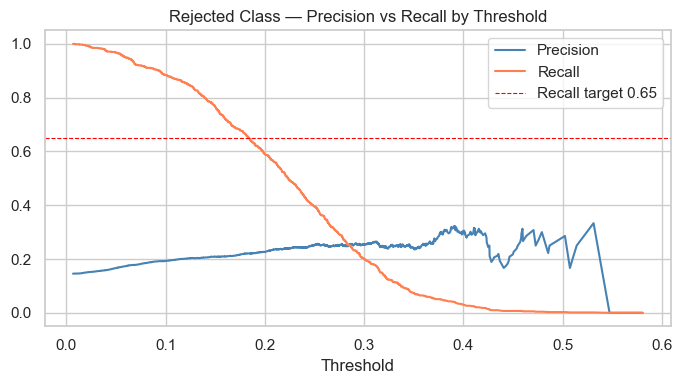

Threshold for Rejected recall ≥ 0.65 : 0.184
Precision at that threshold           : 0.221

=== After threshold tuning ===
Rejected Recall: 0.6511
              precision    recall  f1-score   support

        Paid       0.65      0.61      0.63      2997
     Pending       0.44      0.01      0.03      1275
    Rejected       0.22      0.65      0.33       728

    accuracy                           0.46      5000
   macro avg       0.44      0.43      0.33      5000
weighted avg       0.53      0.46      0.43      5000



In [8]:
proba_test = smote_gb_pipe.predict_proba(X_test)

prec, rec, thresholds = precision_recall_curve(
    (y_test == rej_idx).astype(int), proba_test[:, rej_idx]
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, prec[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, rec[:-1],  label='Recall',    color='coral')
ax.axhline(0.65, color='red', linestyle='--', linewidth=0.8, label='Recall target 0.65')
ax.set_xlabel('Threshold')
ax.set_title('Rejected Class — Precision vs Recall by Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('models/claim_threshold_curve.png', dpi=120)
plt.show()

valid = np.where(rec[:-1] >= 0.65)[0]
if len(valid) > 0:
    opt_thresh = thresholds[valid[-1]]
    print(f'Threshold for Rejected recall ≥ 0.65 : {opt_thresh:.3f}')
    print(f'Precision at that threshold           : {prec[valid[-1]]:.3f}')
else:
    f1_per = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
    opt_thresh = thresholds[np.argmax(f1_per)]
    print(f'Recall 0.65 not achievable; using F1-optimal threshold: {opt_thresh:.3f}')

y_adjusted = np.argmax(proba_test, axis=1).copy()
y_adjusted[proba_test[:, rej_idx] >= opt_thresh] = rej_idx

print('\n=== After threshold tuning ===')
rej_recall_tuned = recall_score(y_test, y_adjusted, labels=[rej_idx], average='macro')
print(f'Rejected Recall: {rej_recall_tuned:.4f}')
print(classification_report(y_test, y_adjusted, target_names=claim_le.classes_))

## 7. Confusion Matrices — Before & After Correction

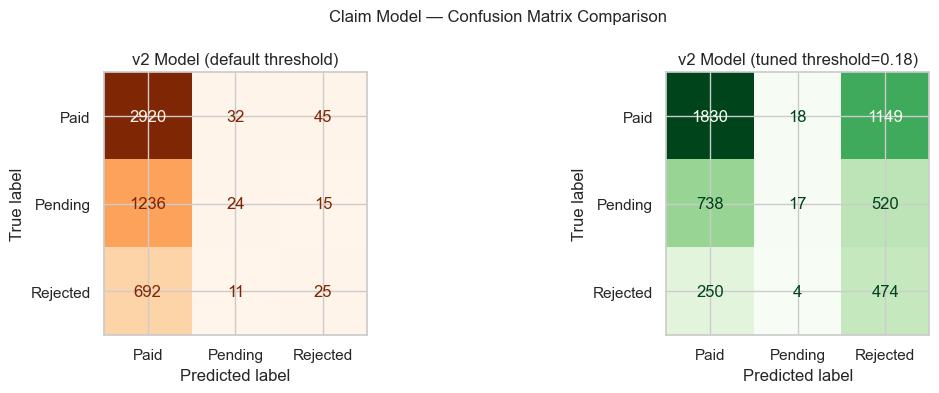

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, display_labels=claim_le.classes_,
    cmap='Oranges', ax=axes[0], colorbar=False
)
axes[0].set_title('v2 Model (default threshold)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_adjusted, display_labels=claim_le.classes_,
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title(f'v2 Model (tuned threshold={opt_thresh:.2f})')

plt.suptitle('Claim Model — Confusion Matrix Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('models/claim_cm_corrected.png', dpi=120)
plt.show()

## 8. Revenue Impact of Improvement

In [10]:
avg_rej_amount = df.loc[df['claim_status'] == 'Rejected', 'billed_amount'].mean()
n_actual_rej   = int((y_test == rej_idx).sum())

v1_missed = int(n_actual_rej * (1 - 0.1236))
v2_missed = int(n_actual_rej * (1 - rej_recall_tuned))

print(f'Actual Rejected cases in test window : {n_actual_rej}')
print(f'Avg billed amount (Rejected)         : ₹{avg_rej_amount:,.0f}')
print(f'v1 missed rejections                 : {v1_missed}  |  Revenue at risk: ₹{v1_missed*avg_rej_amount:,.0f}')
print(f'v2 missed rejections                 : {v2_missed}  |  Revenue at risk: ₹{v2_missed*avg_rej_amount:,.0f}')
print(f'Revenue recovered (est.)             : ₹{(v1_missed-v2_missed)*avg_rej_amount:,.0f}')

Actual Rejected cases in test window : 728
Avg billed amount (Rejected)         : ₹19,723
v1 missed rejections                 : 638  |  Revenue at risk: ₹12,583,051
v2 missed rejections                 : 254  |  Revenue at risk: ₹5,009,553
Revenue recovered (est.)             : ₹7,573,498


## 9. Improvement Summary

                      v1 (baseline)  v2 (corrected)   Delta
Accuracy                     0.5304          0.4642 -0.0662
F1-Macro                     0.3309          0.3285 -0.0024
Rejected Recall              0.1236          0.6511  0.5275
Train-Test Gap (Acc)         0.1300          0.0136 -0.1164


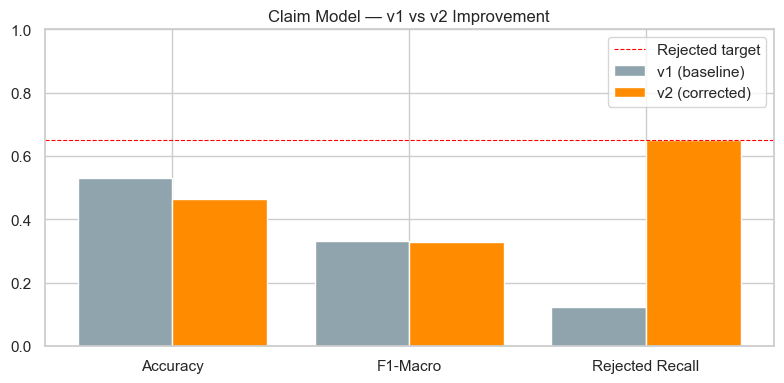

In [11]:
v1 = {'Accuracy': 0.5304, 'F1-Macro': 0.3309, 'Rejected Recall': 0.1236, 'Train-Test Gap (Acc)': 0.130}
v2 = {
    'Accuracy':         accuracy_score(y_test, y_adjusted),
    'F1-Macro':         f1_score(y_test, y_adjusted, average='macro'),
    'Rejected Recall':  recall_score(y_test, y_adjusted, labels=[rej_idx], average='macro'),
    'Train-Test Gap (Acc)': train_acc - test_acc,
}

cmp = pd.DataFrame({'v1 (baseline)': v1, 'v2 (corrected)': v2}).round(4)
cmp['Delta'] = (cmp['v2 (corrected)'] - cmp['v1 (baseline)']).round(4)
print(cmp.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
metrics = ['Accuracy', 'F1-Macro', 'Rejected Recall']
x = np.arange(len(metrics))
ax.bar(x - 0.2, [v1[m] for m in metrics], 0.4, label='v1 (baseline)', color='#90A4AE')
ax.bar(x + 0.2, [v2[m] for m in metrics], 0.4, label='v2 (corrected)', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.axhline(0.65, color='red', linestyle='--', linewidth=0.8, label='Rejected target')
ax.set_ylim(0, 1); ax.set_title('Claim Model — v1 vs v2 Improvement')
ax.legend()
plt.tight_layout()
plt.savefig('models/claim_improvement.png', dpi=120)
plt.show()

## 10. Save Model Artifacts

In [ ]:
joblib.dump(smote_gb_pipe, MODELS_DIR / 'claim_model.joblib')
joblib.dump(claim_le,      MODELS_DIR / 'claim_label_encoder.joblib')
joblib.dump({'threshold': float(opt_thresh), 'rej_idx': rej_idx},
            MODELS_DIR / 'claim_threshold.joblib')

claim_schema = {
    'model': 'claim_model_v2',
    'target': TARGET,
    'target_classes': list(claim_le.classes_),
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'encoded_features': ENCODED_CATS,
    'all_features': ALL_FEATURES,
    'categorical_encodings': le_dict_claim,
    'engineered_features': ['billed_per_hour'],
    'interaction_features': ['bill_vs_dept_avg','bill_x_provider_rate','lag_x_amount','chronic_x_amount'],
    'split_strategy': 'time-based 80/20',
    'cv_strategy': 'TimeSeriesSplit(n_splits=5, gap=200)',
    'imbalance_strategy': 'SMOTE with targeted sampling_strategy inside CV folds',
    'overfit_controls': 'max_depth=4, min_samples_leaf=20, subsample=0.8',
    'threshold_file': 'claim_threshold.joblib',
    'leakage_excluded': ['approved_amount','payment_days','approval_ratio'],
}

schema = json.loads(SCHEMA_PATH.read_text()) if SCHEMA_PATH.exists() else {}
schema['claim_model'] = claim_schema
SCHEMA_PATH.write_text(json.dumps(schema, indent=2))

print('Saved: claim_model.joblib')
print('Saved: claim_label_encoder.joblib')
print('Saved: claim_threshold.joblib')
print('Updated: feature_schema.json')

Saved: claim_model.joblib (v2)
Saved: claim_label_encoder.joblib
Saved: claim_threshold.joblib
Updated: feature_schema.json
